In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt
import sys

sys.path.append("../../scripts")
import readwrite

cfg = readwrite.config()

/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/jbac/miniforge3/envs/spatial/lib/python3.13/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/jbac/miniforge3/envs/spatial/lib/python3.13/site-packages/spatialdata/_core/query/relational_query.py:504: FutureWarning: functools.partial will be a method descriptor in future Python versions; wrap it in enum.member() if you want to preserve the old behavior
  left = partial(_left_join_spatialelement_table)
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/jbac/miniforge3/envs/spatial/lib/python3.13/site-packages/spatialdata/_core/query/relational_query.py:505: FutureWarning: functools.partial will be a method descriptor in future Python versions; wra

## Params

In [2]:
donor_palette = pd.read_csv(cfg['xenium_metadata_dir'] + 'donor_palette.csv',index_col=0)
gene_sets_palette = pd.read_csv(cfg['xenium_metadata_dir'] + 'gene_sets_palette.csv',index_col=0)
cell_type_palette = pd.read_csv(cfg['xenium_metadata_dir'] + 'cell_type_palette.csv',index_col=0)

gene_sets = (
    pd.Series({
        "Mitotic": ["MKI67", "CDK1", "UBE2C", "CENPF", "CD80", "ORC6", "STMN1", "TUBA1B"],
        "Goblet_TFF3": ["TFF3","STMN1","TUBA1B","CEACAM1","CEACAM6","RORC","DGKA","CEACAM8","NT5E","MIS18BP1","ATM","IL22RA1","NOTCH1","TUBB",],
        "Stress": ["AREG","CCL20","IL1A","CDKN2B","ANXA1","CXCL1","ISG15","CD68","ID1","IL1B",
                            "DGKA","CDKN1A","VSIR","CEACAM1","TFF3","CEACAM6","IRF1","CEACAM8","TUBB",],
        "Mesenchymal": ["FN1","CXCL6","C1S","CXCL5","C1R","NCAM1","CD74",],
        "Inflammatory": ["CXCL1","AREG","CDKN2B","CDKN1A","ANXA1"],
        "Goblet_MUC5AC": ["REG4", "MUC5AC", "DMBT1", "CCL28", "FOS", "IQGAP2", "JCHAIN", "IGKC", "TOX", "FAS", "IL1B", "RORC",],
        "Interferon": ["IDO1","MX1","IFIT3","CXCL11","CXCL10","ISG15","IFIT2","IRF1","STAT1","CXCL9",],
}).explode().reset_index())
gene_sets.columns = ["source", "target"]


xenium_dir = Path(cfg["xenium_processed_dir"])
xenium_count_correction_dir = Path(cfg["xenium_count_correction_dir"])
xenium_std_seurat_analysis_dir = Path(cfg["xenium_std_seurat_analysis_dir"])
xenium_cell_type_annotation_dir = Path(cfg["xenium_cell_type_annotation_dir"])
results_dir = Path(cfg["results_dir"])

# input params
cellcharter_dir = "cellcharter_cohort"
correction_method = "raw"
segmentation = "proseg_expected"
condition = ["CRC_PDO","CRC_PDO_CAF","CRC_PDO_DEV"]
panel = "all"
normalisation = "lognorm"
reference = "GEO_GSE178341"
method = "rctd_class_aware"
level = "Level1"
xenium_levels = ["segmentation", "condition", "panel", "donor", "sample"]
name_malignant = "Epi"

# qc params
min_n_counts = 20

# fixed params
BATCH_KEY = "dataset_id"
SPATIAL_KEY = "spatial"

segmentations_filter = [segmentation]
conditions_filter = condition
panels_filter = [panel] if panel != "all" else None

# Read results

In [5]:
# read samples
xenium_paths, xenium_annot_paths = readwrite.discover_xenium_paths(
    analysis_dir=xenium_std_seurat_analysis_dir,
    data_dir=xenium_dir,
    annotation_dir=xenium_cell_type_annotation_dir,
    correction_dir=xenium_count_correction_dir,
    normalisation=normalisation,
    reference=reference,
    method=method,
    level=level,
    correction_methods_filter=[correction_method],
    segmentations_filter=[segmentation],
    conditions_filter=conditions_filter,
    panels_filter=panels_filter,
)


# set transcripts=True to load individual transcripts positions)
sds = {}
sds["raw"] = readwrite.read_xenium_samples(
    xenium_paths["raw"], anndata=False, 
    cells_boundaries=True,
    pool_mode="thread", max_workers=6)

/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/jbac/miniforge3/envs/spatial/lib/python3.13/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/jbac/miniforge3/envs/spatial/lib/python3.13/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/workflow/analysis/xenium/../../scripts/readwrite.py:352: UserWarning: 
                Couldn't load xenium specs file with pixel size. 
                Not applying scale transformations to shapes.
                Please specify xeniumranger_dir or xenium_specs
                
  warnings.warn(
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/workflow/analysis/xenium/../../scripts/readwrite.py:352: User

## segment organoids

In [27]:
import geopandas as gpd
from shapely.geometry import Polygon
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components

# Distance threshold
r = 0

for k, sd in sds["raw"].items():
    gdf = sd['cells_boundaries']

    # Candidate pairs (bounding boxes padded by r)
    pairs = []
    for i, geom in enumerate(gdf.geometry):
        hits = list(gdf.sindex.query(geom.buffer(r)))
        for j in hits:
            if i < j and geom.distance(gdf.geometry[j]) <= r:
                pairs.append((i, j))

    rows, cols = zip(*pairs) if pairs else ([], [])

    keep_rows, keep_cols = [], []

    for i, j in zip(rows, cols):
        if i >= j:   # avoid duplicate/self
            continue
        if gdf.geometry[i].distance(gdf.geometry[j]) <= r:
            keep_rows.append(i)
            keep_cols.append(j)

    # Build adjacency matrix
    n = len(gdf)
    data = [1] * len(keep_rows)
    A = csr_matrix((data, (keep_rows, keep_cols)), shape=(n, n))

    # Symmetrize (since graph is undirected)
    A = A + A.T

    # Connected components
    n_components, labels = connected_components(A, directed=False)
    gdf["cluster_id"] = labels
    break


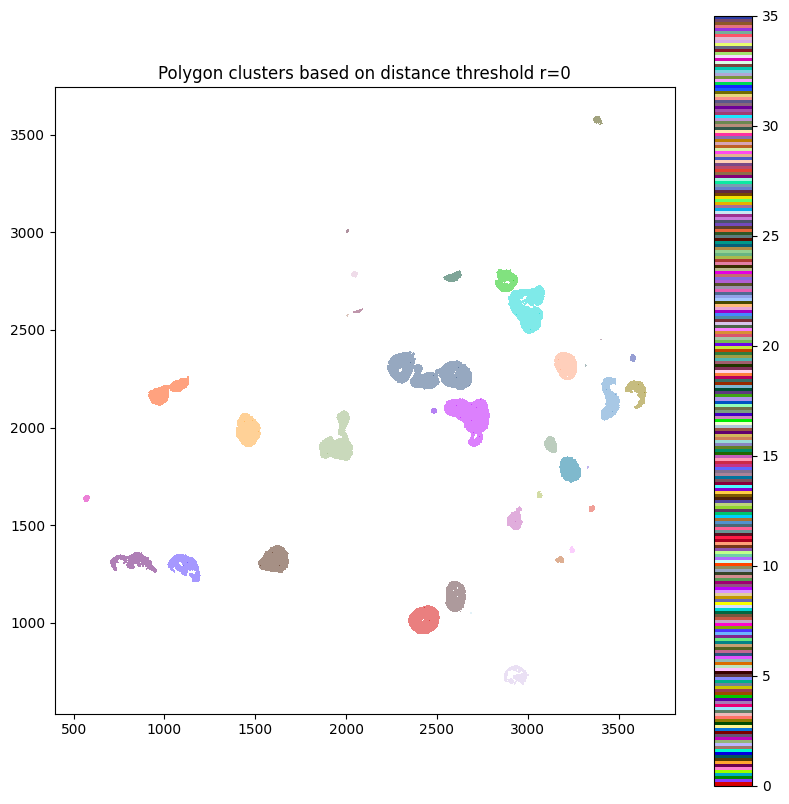

In [31]:
import matplotlib.pyplot as plt
import colorcet as cc

# Plot all polygons, colored by cluster_id
fig, ax = plt.subplots(figsize=(10, 10))
gdf.plot(column="cluster_id", cmap=cc.cm.glasbey, legend=True, ax=ax,alpha=.5)
ax.set_title("Polygon clusters based on distance threshold r={}".format(r))
plt.show()
